# Expected-distance ambiguity set vs Ball around expected value

In our work, we propose the expected-distance ambiguity set: It consists of distributions $Q$ such that $\mathbb{E}_{\theta \sim \Pi}[d(Q, P_\theta)] \leq \epsilon$, where $\Pi$ is the posterior distribution and $\theta$ is a parameter of the likelihood distribution $P_\theta$.

In contrast, one could draw a ball of radius $\epsilon$ around the posterior predictive distribution: It contains distributions $Q$ such that $d(Q, \mathbb{E}_{\theta \sim \Pi}[P_\theta]) \leq \epsilon$.

The goal of this notebook is to visualise the difference between an expected-distance set and a ball drawn around the expected value.
To simplify the visualisation, we draw uncertainty sets from robust optimisation which are analogous to ambiguity sets in our setting.
Our uncertainty sets will contain real-valued vectors instead of probability distribution.

Specifically, let $\Zeta$ be a distribution with support $\mathbb{R}^2$ which represent the posterior distribution $\Pi$ in this analogy.
We use the $\ell_2$ norm for our distance.
The expected-distance uncertainty set~$U_1$ is defined by:
$$U_1 \triangleq \{ y \in \mathbb{R}^2: \mathbb{E}_{z \sim \Zeta}[\Vert y - z \Vert_2] \leq \epsilon \}.$$
The "ball around expected value" uncertainty set~$U_2$ is defined by:
$$U_2 \triangleq \{ y \in \mathbb{R}^2: \Vert y - \mathbb{E}_{z \sim \Zeta}[z] \Vert_2 \leq \epsilon \}.$$

### How to construct and draw the sets

Set $U_2$ is relatively straight forward to construct.
After taking samples from distribution $\Zeta$, we find the empirical mean of the samples, then draw a circle of radius $\epsilon$ around the empirical mean.

Set $U_1$ is not so simple. Our procedure is:
1. Take samples from $\Zeta$.
2. Draw a grid covering the data space of empirical samples.
3. For each grid point $y$, we calcuate the expected distance $\mathbb{E}_{z \sim \Zeta}[\Vert y - z \Vert_2]$.
4. If the expected distance is at most $\epsilon$, then we put point $y$ in the set $U_1$.
5. Compute the convex hull of all points in $U_1$ and finally draw the convex hull using matplotlib.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

In [7]:
def expected_distance(y: np.array, z_samples: np.array):
    """For each point y in the grid, calculate the expected distance from y to points sampled from z"""
    return np.mean(np.linalg.norm(z_samples - y, axis=1))

vec_expected_distance = np.vectorize(expected_distance)

def get_regular_grid(z_samples: np.array, epsilon: float) -> np.array:
    """Get a grid that easily covers the epsilon ball"""
    n_points = 200
    margin = 0.2
    z_mean = np.mean(z_samples, axis=0)
    x_axis = np.linspace(
        start=min(np.min(z_samples[:, 0]), z_mean[0] - epsilon - margin), 
        stop=max(np.max(z_samples[:, 0]), z_mean[0] + epsilon + margin),
        num=n_points,
    )
    y_axis = np.linspace(
        start=min(np.min(z_samples[:, 1]), z_mean[1] - epsilon - margin),
        stop=max(np.max(z_samples[:, 1]), z_mean[1] + epsilon + margin),
        num=n_points
    )
    xv, yv = np.array(np.meshgrid(x_axis, y_axis))
    return np.array([xv.flatten(), yv.flatten()]).T

In [33]:
generator = np.random.default_rng(seed=0)
n_samples = 20
z_samples_dict = {}
DISTRIBUTIONS = ["multivariate_normal", "multivariate_t", "exponential"]
for z_dist in DISTRIBUTIONS:
    if z_dist == "multivariate_normal":
        z_samples = generator.multivariate_normal(np.zeros(2), np.array([[2.0, -0.75], [-0.75, 1.0]]), n_samples)
    elif z_dist == "exponential":
        z_samples = generator.exponential(np.array([0.5, 1.5]), (n_samples, 2))
    elif z_dist == "multivariate_t":
        T = sp.stats.multivariate_t(loc=np.zeros(2), shape=np.array([[2.0, -0.75], [-0.75, 1.0]]), df=5.0, seed=generator)
        z_samples = T.rvs(size=n_samples)
    z_samples_dict[z_dist] = z_samples

In [34]:
grid_dict = {}
exp_distance_matrix = {}
EPSILON_LIST = [2.0, 3.0, 4.0]
for z_dist in DISTRIBUTIONS:
    grid_dict[z_dist] = []
    for epsilon in EPSILON_LIST:
        z_samples = z_samples_dict[z_dist]
        grid_dict[z_dist].append(get_regular_grid(z_samples_dict[z_dist], epsilon))

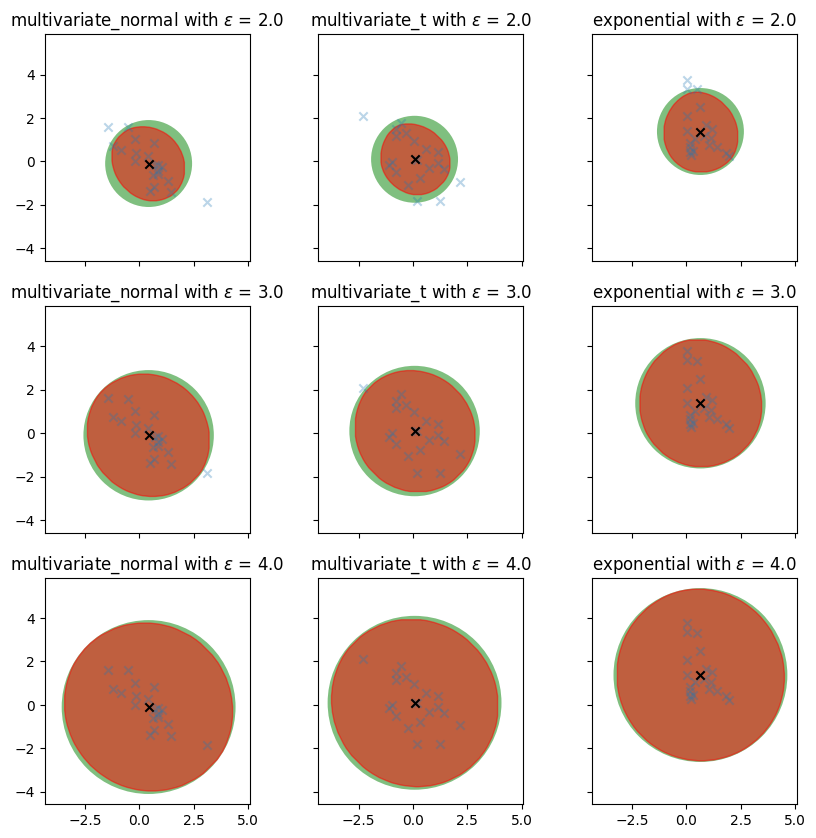

In [35]:
fig, axes = plt.subplots(nrows=len(EPSILON_LIST), ncols=len(DISTRIBUTIONS), figsize=(10,10), sharex=True, sharey=True)

for e_idx, epsilon in enumerate(EPSILON_LIST):
    for d_idx, z_dist in enumerate(DISTRIBUTIONS):
        ax = axes[e_idx][d_idx]
        ax.set_title(f"{z_dist} with $\epsilon$ = {epsilon}")
        grid = grid_dict[z_dist][e_idx]
        z_samples = z_samples_dict[z_dist]
        M = np.array([expected_distance(y, z_samples) for y in grid])
        in_U1 = grid[M <= epsilon]

        # draw U2
        expected_z = np.mean(z_samples, axis=0)
        epsilon_ball = mpl.patches.Circle(expected_z, radius=epsilon, alpha=0.5, fc='green')
        ax.add_patch(epsilon_ball)

        # draw U1
        hull = sp.spatial.ConvexHull(in_U1)
        xy = np.array([in_U1[hull.vertices, 0], in_U1[hull.vertices, 1]]).T
        polygon = mpl.patches.Polygon(xy, alpha=0.5, color="red")
        ax.add_patch(polygon)

        # draw samples
        ax.scatter(z_samples[:,0], z_samples[:, 1], alpha=0.3, marker="x")

        # mark expected value
        ax.scatter(expected_z[0], expected_z[1], color="black", alpha=1, marker="x")

        # ax.set_xlim(-6, 6)
        # ax.set_ylim(-6, 6)
        ax.set(adjustable="box", aspect='equal')
fig.show()